# Análisis Exploratorio y Limpieza — Catálogo de Series StreamView Analytics

Este notebook replica la metodología utilizada para películas, adaptada al dataset `netflix_tv_shows_detailed_up_to_2025.csv`.

**Objetivo:** identificar patrones de popularidad, calificación y géneros en las series, documentando además la calidad y las limitaciones de la fuente.

## 1. Configuración del entorno y carga de datos

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(9,5.5)
ruta_datos='netflix_tv_shows_detailed_up_to_2025.csv'
df=pd.read_csv(ruta_datos, na_values=['','NULL','null','N/A','n/a','NaN'])
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 16000 filas, 16 columnas


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


## 2. Diccionario de variables clave

`show_id`: identificador; `type`: tipo de contenido; `title`: título; `director`: director; `cast`: reparto; `country`: país(es); `date_added`: fecha de incorporación; `release_year`: año de estreno; `rating`: duplicado de `vote_average`; `duration`: duración; `genres`: género(s); `language`: idioma; `description`: sinopsis; `popularity`: índice de popularidad; `vote_count`: cantidad de votos; `vote_average`: calificación promedio.

## 3. Inspección de datos

In [3]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nDuplicados exactos:', df.duplicated().sum())
print('\nResumen estadístico:')
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB

Valores nulos por columna:
show_id             0
type

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,16000.0,NaN,NaN,NaN,126567.673375,75640.760545,767.0,67867.75,94380.5,206920.75,285345.0
type,16000,1,TV Show,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,16000,15668,The Voice Kids,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5035,3808,Don Michael Perez,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,14843,14628,"Qing Zu, Deng Yuting, Ying Liang, Hongyun Liu,...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,14203,564,United States of America,2339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,16000,4899,2025-03-01,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,16000.0,NaN,NaN,NaN,2017.5,4.609916,2010.0,2013.75,2017.5,2021.25,2025.0
rating,16000.0,NaN,NaN,NaN,5.417107,3.266492,0.0,2.7,6.8,7.8,10.0
duration,16000,1,1 Seasons,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Hallazgos de calidad

- El dataset contiene 16.000 series y 16 columnas.
- No hay duplicados exactos.
- `rating` es idéntica a `vote_average` en el 100% de los registros y no aporta información adicional.
- `duration` contiene `1 Seasons` en el 100% de los registros, por lo que no permite diferenciar duración y se considera no informativa para este análisis.
- Existen valores faltantes en director, descripción, país, reparto y géneros.
- Hay 3.674 registros con `vote_count = 0`; para análisis de calificación se excluirán porque una calificación cero puede representar ausencia de votos.

## 4. Limpieza de datos

In [4]:
df_clean=df.copy()
df_clean=df_clean.drop(columns=['rating','duration'], errors='ignore')
df_clean['date_added']=pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean['is_duplicate_title_year']=df_clean.duplicated(['title','release_year'], keep=False)
print('Columnas eliminadas: rating, duration')
print('Duplicados título+año detectados:', int(df_clean['is_duplicate_title_year'].sum()))
print('Registros finales:', len(df_clean))

Columnas eliminadas: rating, duration
Duplicados título+año detectados: 87
Registros finales: 16000


## 5. Distribución de variables numéricas

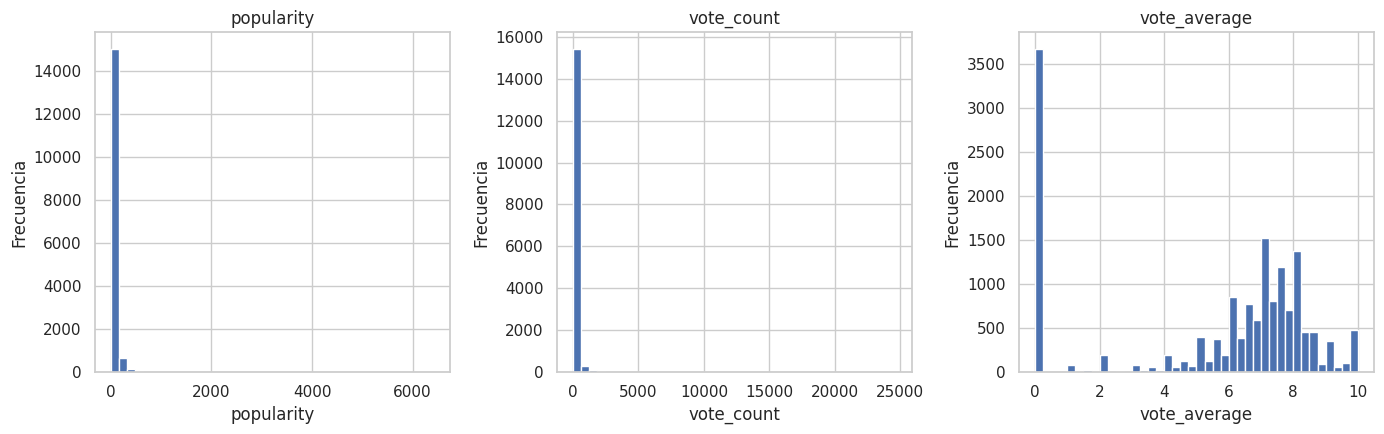

In [5]:
fig,axs=plt.subplots(1,3,figsize=(14,4.5))
for ax,col in zip(axs,['popularity','vote_count','vote_average']):
    ax.hist(df_clean[col].dropna(),bins=40); ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

## 6. Distribución de popularidad

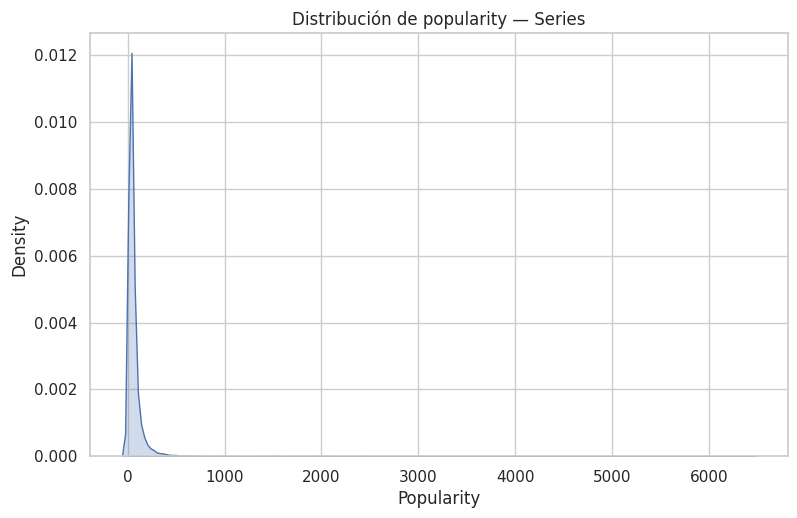

In [6]:
sns.kdeplot(df_clean['popularity'].dropna(), fill=True)
plt.title('Distribución de popularity — Series'); plt.xlabel('Popularity'); plt.show()

### Interpretación
`popularity` presenta una distribución asimétrica: la mayoría de los títulos se concentra en valores relativamente bajos y una cantidad pequeña alcanza valores muy altos. Esto justifica complementar el promedio con medianas y revisar outliers.

## 7. Análisis por género

In [7]:
df_gen=df_clean.copy()
df_gen['genres']=df_gen['genres'].str.split(',')
df_gen=df_gen.explode('genres')
df_gen['genres']=df_gen['genres'].str.strip()
pop_por_genero=df_gen.groupby('genres')['popularity'].mean().sort_values(ascending=False)
pop_por_genero.head(10)

,popularity
genres,
Soap,155.458014
Talk,130.431064
News,102.000292
Western,97.959250
Family,81.534754
Reality,79.269336
Action & Adventure,67.400170
Kids,66.362344
Comedy,66.329217


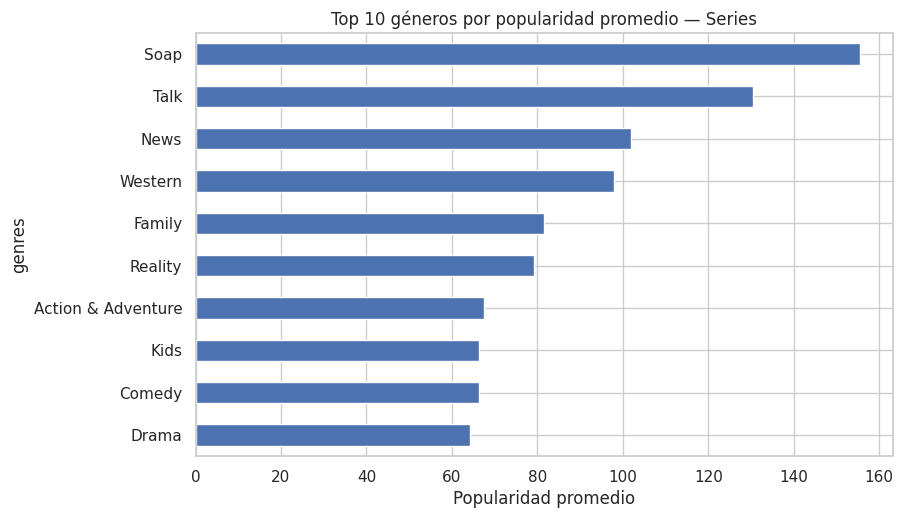

In [8]:
pop_por_genero.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 géneros por popularidad promedio — Series'); plt.xlabel('Popularidad promedio'); plt.show()

### Hallazgo
En la fuente analizada, los géneros con mayor popularidad promedio incluyen Soap, Talk, News, Western y Family. Estos resultados describen el catálogo disponible y deben interpretarse considerando que una serie puede pertenecer a varios géneros.

## 8. Volumen del catálogo por género

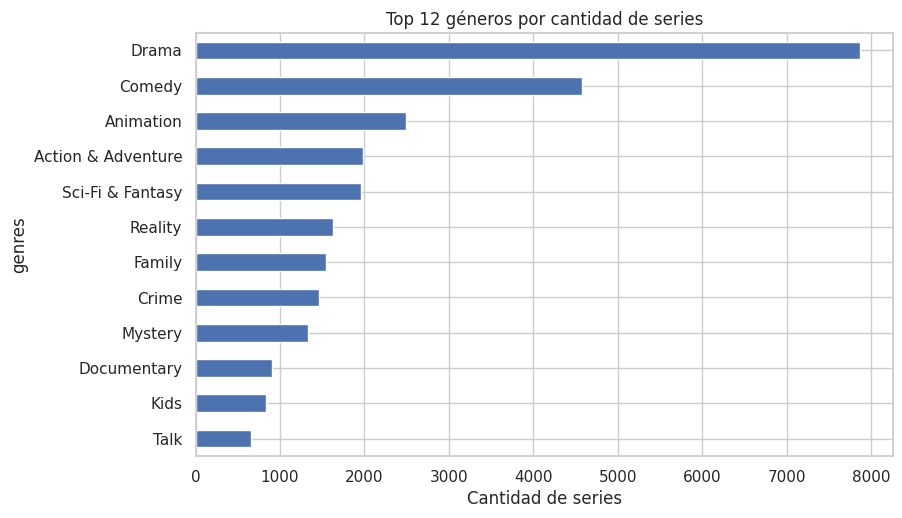

In [9]:
volumen_genero=df_gen['genres'].value_counts().head(12).sort_values()
volumen_genero.plot(kind='barh')
plt.title('Top 12 géneros por cantidad de series'); plt.xlabel('Cantidad de series'); plt.show()

## 9. Evolución por año de estreno

release_year
2010    1000
2011    1000
2012    1000
2013    1000
2014    1000
2015    1000
2016    1000
2017    1000
2018    1000
2019    1000
2020    1000
2021    1000
2022    1000
2023    1000
2024    1000
2025    1000
dtype: int64


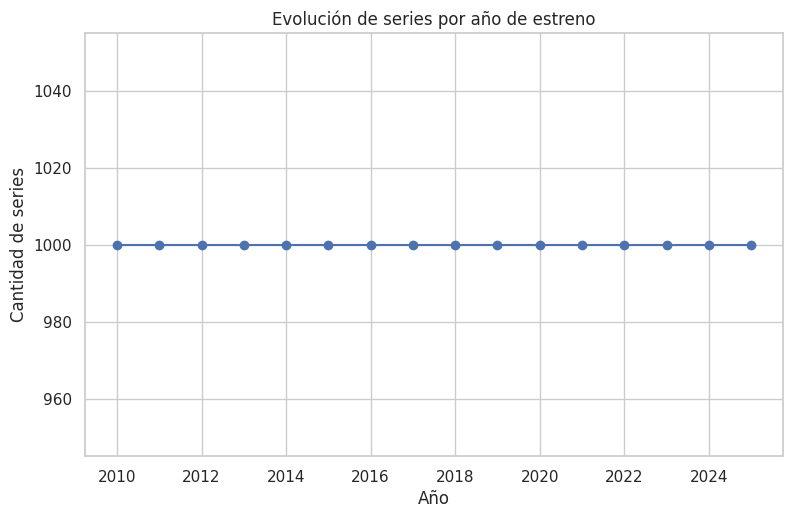

In [10]:
evolucion=df_clean.groupby('release_year').size()
print(evolucion)
evolucion.plot(marker='o')
plt.title('Evolución de series por año de estreno'); plt.xlabel('Año'); plt.ylabel('Cantidad de series'); plt.show()

### Limitación detectada en la fuente
**El dataset original contiene exactamente 1.000 registros para cada año entre 2010 y 2025.** Por lo tanto, la línea de evolución es plana por construcción de la fuente. No corresponde modificar estos valores para forzar una tendencia. En el informe se debe declarar esta limitación y evitar interpretar este gráfico como una evolución real del volumen de estrenos.

## 10. Calificación por género

In [11]:
df_con_votos=df_clean[df_clean['vote_count']>0].copy()
df_cal=df_con_votos.copy(); df_cal['genres']=df_cal['genres'].str.split(','); df_cal=df_cal.explode('genres'); df_cal['genres']=df_cal['genres'].str.strip()
calificacion_por_genero=df_cal.groupby('genres')['vote_average'].mean().sort_values(ascending=False)
calificacion_por_genero.head(10)

,vote_average
genres,
War & Politics,7.475287
Documentary,7.414944
Action & Adventure,7.401462
Sci-Fi & Fantasy,7.387852
Animation,7.332033
Western,7.256385
Crime,7.214447
Mystery,7.203795
Kids,7.201909


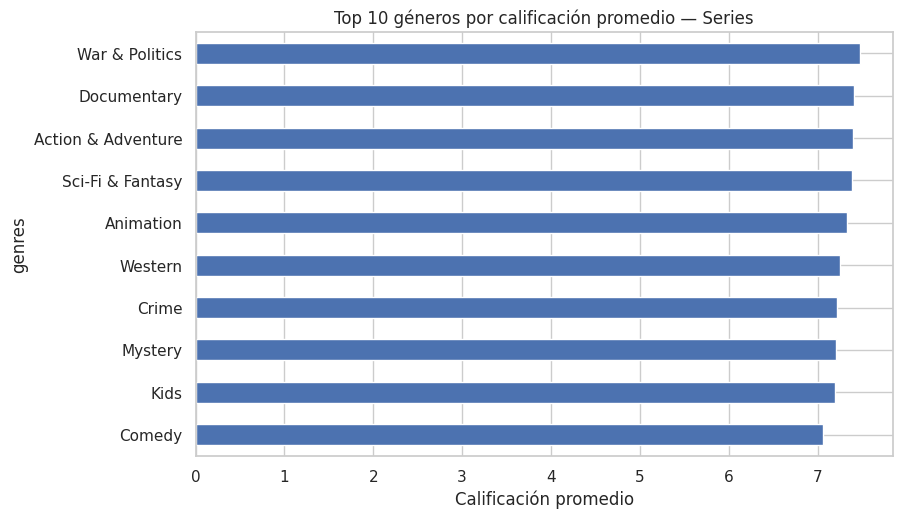

In [12]:
calificacion_por_genero.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 géneros por calificación promedio — Series'); plt.xlabel('Calificación promedio'); plt.show()

### Interpretación
La calificación promedio por género se calcula solo sobre series con al menos un voto. En la fuente, War & Politics, Documentary, Action & Adventure, Sci-Fi & Fantasy y Animation aparecen entre los géneros con mayores promedios.

## 11. Valores atípicos

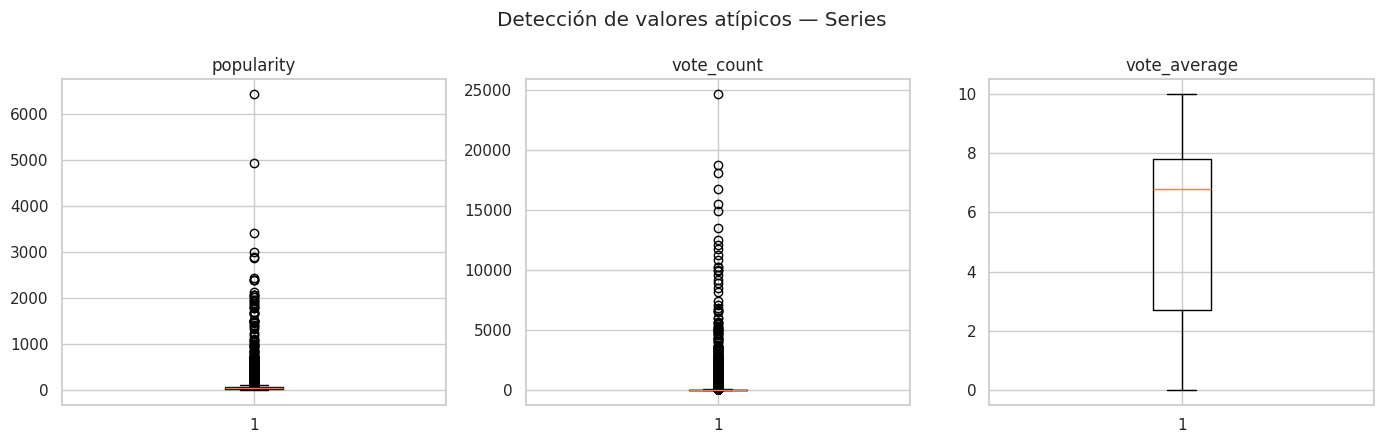

In [13]:
fig,axs=plt.subplots(1,3,figsize=(14,4.5))
for ax,col in zip(axs,['popularity','vote_count','vote_average']):
    ax.boxplot(df_clean[col].dropna(),vert=True); ax.set_title(col)
plt.suptitle('Detección de valores atípicos — Series'); plt.tight_layout(); plt.show()

### Decisión sobre outliers
No se eliminan automáticamente. Los valores extremos de popularidad y votos pueden corresponder a títulos de alto interés y son relevantes para el análisis. Se recomienda usar medidas robustas y comunicar la dispersión.

## 12. Correlación

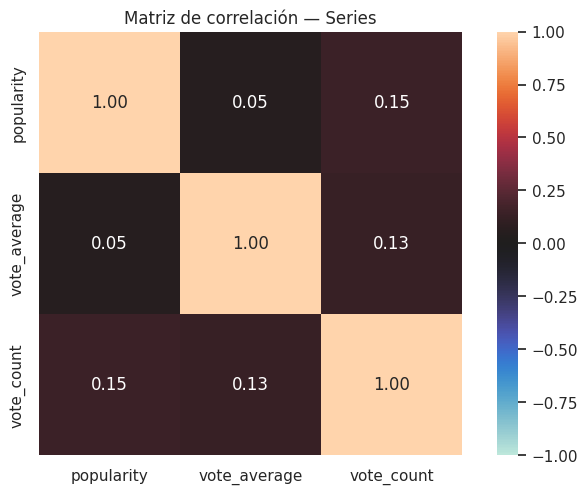

              popularity  vote_average  vote_count
popularity      1.000000      0.052165    0.145118
vote_average    0.052165      1.000000    0.131719
vote_count      0.145118      0.131719    1.000000


In [14]:
cols=['popularity','vote_average','vote_count']
corr=df_clean[cols].corr()
sns.heatmap(corr,annot=True,fmt='.2f',center=0,vmin=-1,vmax=1,square=True)
plt.title('Matriz de correlación — Series'); plt.show()
print(corr)

### Interpretación
La matriz permite revisar la relación lineal entre popularidad, cantidad de votos y calificación. Estas correlaciones deben interpretarse como asociaciones y no como causalidad.

## 13. Preparación para el dashboard

In [16]:
from pathlib import Path
Path('data/processed').mkdir(parents=True, exist_ok=True)
df_clean.to_csv('data/processed/tv_shows_clean.csv',index=False)

df_gen_votos=df_con_votos.copy()
df_gen_votos['genres']=df_gen_votos['genres'].str.split(',')
df_gen_votos=df_gen_votos.explode('genres')
df_gen_votos['genres']=df_gen_votos['genres'].str.strip()
resumen_tv=(df_gen_votos.groupby('genres').agg(popularidad_promedio=('popularity','mean'),calificacion_promedio=('vote_average','mean'),cantidad_series=('show_id','nunique')).sort_values('popularidad_promedio',ascending=False))
resumen_tv.to_csv('data/processed/resumen_por_genero_tv_shows.csv')
print('Exportados: tv_shows_clean.csv y resumen_por_genero_tv_shows.csv')

Exportados: tv_shows_clean.csv y resumen_por_genero_tv_shows.csv


## 14. Conclusiones

1. La fuente contiene 16.000 series, sin duplicados exactos.
2. `rating` es redundante respecto de `vote_average` y `duration` es constante, por lo que ambas se eliminan del dataset limpio.
3. Existen faltantes principalmente en director, descripción, país, reparto y géneros; no se imputan automáticamente porque hacerlo podría inventar información.
4. La popularidad presenta fuerte asimetría y valores extremos, por lo que no deben eliminarse automáticamente.
5. Para calificaciones por género se excluyen registros sin votos.
6. La evolución por año no permite identificar una tendencia porque la fuente contiene exactamente 1.000 registros por año entre 2010 y 2025. Esta limitación debe declararse en el informe.